<a href="https://colab.research.google.com/github/KKKaimin/deep-learning-journey/blob/main/DL_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("Sum:", a + b)
print("Dot product:", np.dot(a, b))
print("Matrix multiply:", np.outer(a, b))

Sum: [5 7 9]
Dot product: 32
Matrix multiply: [[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]


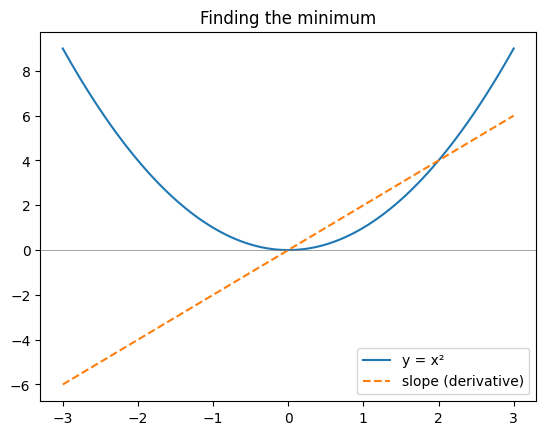

"\n\n> 💡 Training a neural network = repeatedly computing derivatives to slide toward the minimum loss. That's it.\n\n---\n\n### ⛓️ The Chain Rule — why it's everything\n\nNeural networks have **many layers stacked on top of each other**. To train them, you need to know how changing an early weight affects the final output. The chain rule lets you do that.\n\nThink of it like this:\n```\nInput → Layer 1 → Layer 2 → Output → Loss\n"

In [3]:
# Example: y = x²
# The derivative is: dy/dx = 2x
# Meaning: at x=3, the slope is 6 (output grows fast)
#          at x=0, the slope is 0 (we're at the bottom — minimum!)

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 100)
y = x**2
slope = 2*x   # the derivative

plt.plot(x, y, label='y = x²')
plt.plot(x, slope, label="slope (derivative)", linestyle='--')
plt.axhline(0, color='gray', linewidth=0.5)
plt.legend()
plt.title("Finding the minimum")
plt.show()
"""

> 💡 Training a neural network = repeatedly computing derivatives to slide toward the minimum loss. That's it.

---

### ⛓️ The Chain Rule — why it's everything

Neural networks have **many layers stacked on top of each other**. To train them, you need to know how changing an early weight affects the final output. The chain rule lets you do that.

Think of it like this:
```
Input → Layer 1 → Layer 2 → Output → Loss
"""

In [4]:
import numpy as np

# Simulate one gradient descent step
x = 10.0          # starting point
learning_rate = 0.1

for step in range(10):
    loss = x**2           # we want to minimize x²
    gradient = 2 * x      # derivative of x²
    x = x - learning_rate * gradient   # step downhill
    print(f"Step {step+1}: x={x:.4f}, loss={loss:.4f}")

# Watch x get closer and closer to 0!

Step 1: x=8.0000, loss=100.0000
Step 2: x=6.4000, loss=64.0000
Step 3: x=5.1200, loss=40.9600
Step 4: x=4.0960, loss=26.2144
Step 5: x=3.2768, loss=16.7772
Step 6: x=2.6214, loss=10.7374
Step 7: x=2.0972, loss=6.8719
Step 8: x=1.6777, loss=4.3980
Step 9: x=1.3422, loss=2.8147
Step 10: x=1.0737, loss=1.8014


In [6]:
import numpy as np

# Build a tiny prediction evaluator
def evaluate(predictions, true_label):
    probs = softmax(predictions)
    loss = cross_entropy_loss(probs[true_label])
    confidence = probs[true_label] * 100
    print(f"Probabilities: {np.round(probs, 3)}")
    print(f"Confidence in correct class: {confidence:.1f}%")
    print(f"Loss: {loss:.3f}")

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def cross_entropy_loss(p):
    return -np.log(p)

# Try tweaking these scores and see what happens!
predictions = [0.1, 3.0, 0.2]   # model's raw output
true_label = 0                   # correct answer is class 0

evaluate(predictions, true_label)

Probabilities: [0.049 0.896 0.054]
Confidence in correct class: 4.9%
Loss: 3.010


In [8]:
import pandas as pd
import numpy as np

# Load the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Answer these 3 questions with code:

# Q1: What % of passengers survived?
print("Survival rate:", df['Survived'].mean() * 100, "%")

# Q2: Did women survive more than men?
print(df.groupby('Sex')['Survived'].mean() * 100)

# Q3: What was the average age of survivors vs non-survivors?
print(df.groupby('Survived')['Age'].mean())

# 🎯 Challenge: What's the survival rate by Pclass AND Sex combined?
# Hint: groupby accepts a list: groupby(['col1', 'col2'])

Survival rate: 38.38383838383838 %
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64
Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64


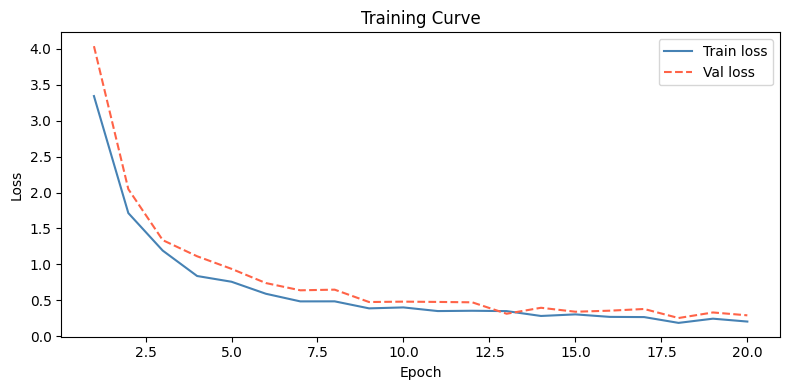

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated training — watch loss drop over epochs
epochs = range(1, 21)
train_loss = [1/(0.3*e) + np.random.rand()*0.1 for e in epochs]
val_loss   = [1/(0.25*e) + np.random.rand()*0.15 for e in epochs]

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss, label='Train loss', color='steelblue')
plt.plot(epochs, val_loss,   label='Val loss',   color='tomato', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

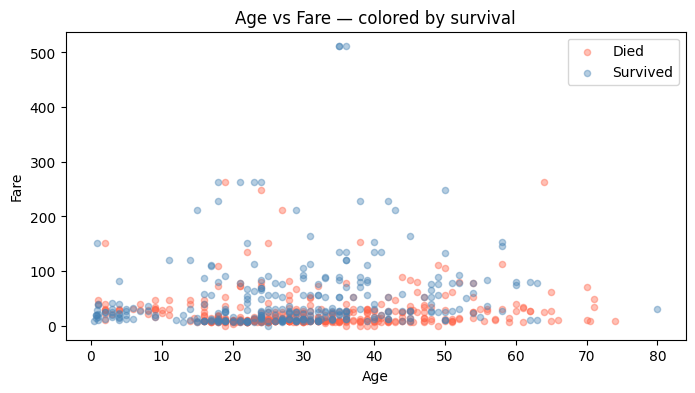

In [10]:
# Does fare correlate with survival?
survivors    = df[df['Survived'] == 1]
non_survivors = df[df['Survived'] == 0]

plt.figure(figsize=(8, 4))
plt.scatter(non_survivors['Age'], non_survivors['Fare'],
            alpha=0.4, label='Died',     color='tomato',    s=20)
plt.scatter(survivors['Age'],     survivors['Fare'],
            alpha=0.4, label='Survived', color='steelblue', s=20)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare — colored by survival')
plt.legend()
plt.show()

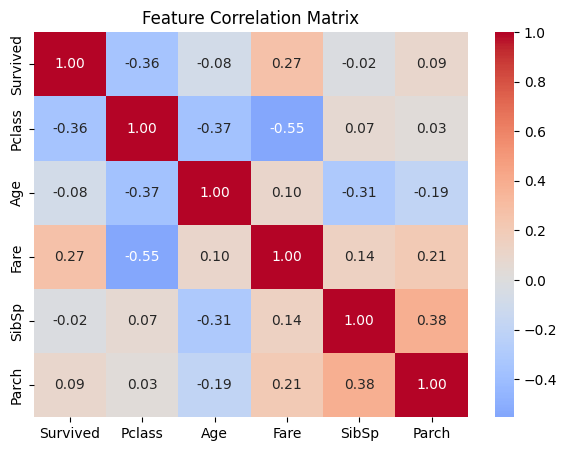

In [11]:
import seaborn as sns   # built on matplotlib, much prettier

numeric_cols = df[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']].dropna()

plt.figure(figsize=(7, 5))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

Survival rate: 0.384
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Probabilities: [0.80953975 0.16344326 0.02701699]


/tmp/ipython-input-516/3941961198.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


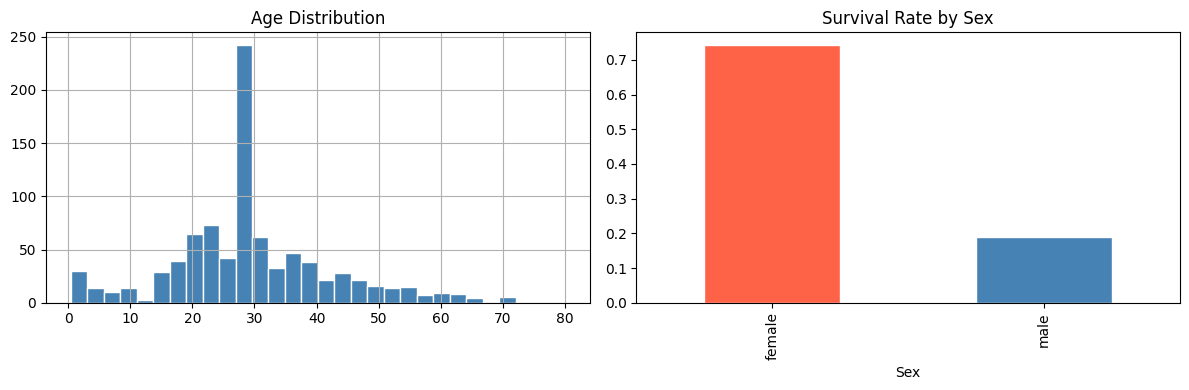

🎉 Phase 1 complete!


In [12]:
# ── PHASE 1 CAPSTONE ─────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# 1. NUMPY: compute survival stats manually
survived = df['Survived'].values
print("Survival rate:", np.mean(survived).round(3))

# 2. PANDAS: clean & explore
df['Age'].fillna(df['Age'].median(), inplace=True)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print(df.groupby('Pclass')['Survived'].mean())

# 3. PROBABILITY: softmax on fake scores
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

print("Probabilities:", softmax([2.1, 0.5, -1.3]))

# 4. MATPLOTLIB: dashboard
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Age'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1],
    color=['tomato','steelblue'], edgecolor='white')
axes[1].set_title('Survival Rate by Sex')
plt.tight_layout()
plt.show()

print("🎉 Phase 1 complete!")